# 📈 Sales Prediction Using Python

### CodeAlpha Data Science Internship – Task 4



**Intern Name:** Radhika

**Platform:** Google Colab

**Programming Language:** Python



## 📌 Project Objective

The objective of this project is to predict product sales based on advertising expenditure across different media channels such as TV, Radio, and Newspaper.

Machine Learning techniques are used to analyze the relationship between advertising budgets and sales performance.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from google.colab import files
uploaded = files.upload()

data = pd.read_csv("Advertising.csv")

Saving Advertising.csv to Advertising (1).csv


## Dataset Overview

The dataset contains advertising expenditure across multiple marketing channels and corresponding sales figures.

In [ ]:
data.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [ ]:
data.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [ ]:
data.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


## Data Cleaning

The dataset is checked for missing values and inconsistencies before model development.

In [ ]:
data.shape

(200, 5)

In [ ]:
data.columns

Index(['Unnamed: 0', 'TV', 'Radio', 'Newspaper', 'Sales'], dtype='object')

In [ ]:
if 'Unnamed: 0' in data.columns:
    data.drop('Unnamed: 0', axis=1, inplace=True)

In [ ]:
data.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


## Exploratory Data Analysis (EDA)

Visualizations are used to understand relationships between advertising expenditure and sales.

### Correlation Heatmap
A correlation heatmap is used to measure the strength of relationships between variables. Higher correlation values indicate a stronger impact on sales performance.

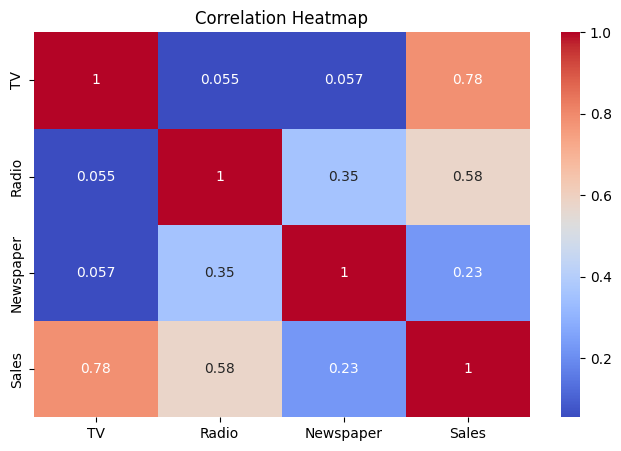

In [ ]:
plt.figure(figsize=(8,5))
sns.heatmap(data.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

### TV Advertising vs Sales
This scatter plot shows the relationship between TV advertising expenditure and sales. It helps determine whether increased TV advertising contributes to higher sales.

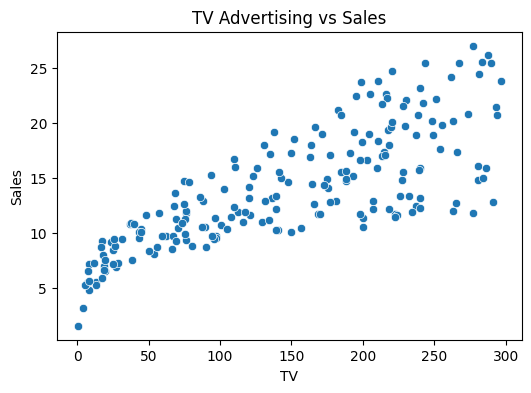

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='TV', y='Sales', data=data)
plt.title("TV Advertising vs Sales")
plt.show()

### Radio Advertising vs Sales
The plot illustrates the relationship between radio advertising budgets and sales. It helps identify the effectiveness of radio advertisements in generating revenue.

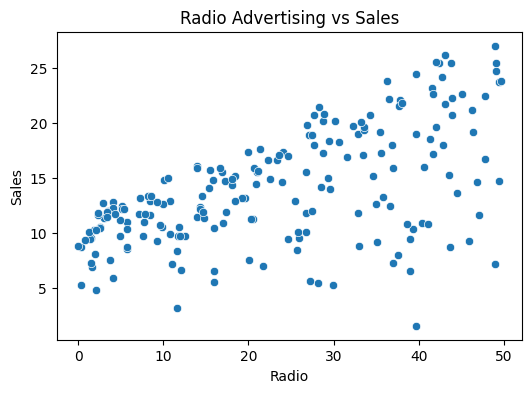

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Radio', y='Sales', data=data)
plt.title("Radio Advertising vs Sales")
plt.show()

### Newspaper Advertising vs Sales
This visualization examines how newspaper advertising expenditure affects sales performance and whether a significant relationship exists.

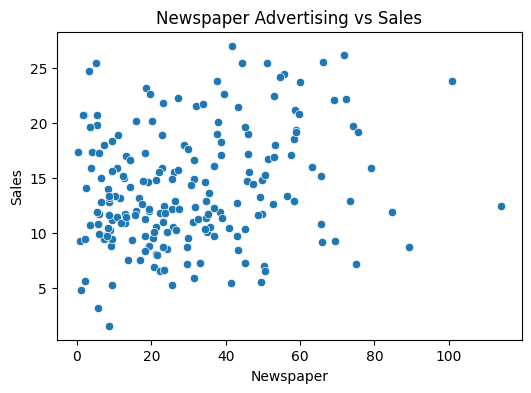

In [ ]:
plt.figure(figsize=(6,4))
sns.scatterplot(x='Newspaper', y='Sales', data=data)
plt.title("Newspaper Advertising vs Sales")
plt.show()

## 🤖 Model Building
Machine Learning techniques are applied to build a predictive model that estimates product sales based on advertising expenditure across different marketing channels.

### Feature Selection
The independent variables (TV, Radio, and Newspaper) are selected as features, while Sales is considered the target variable.

In [ ]:
X = data[['TV','Radio','Newspaper']]
y = data['Sales']

### Data Splitting
The dataset is divided into training and testing sets. The training data is used to train the model, while the testing data is used to evaluate performance.

In [ ]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X,y,
    test_size=0.2,
    random_state=42
)

### Linear Regression Model
Linear Regression is used to establish a relationship between advertising expenditure and sales. The model learns patterns from historical data and predicts future sales.

In [ ]:
from sklearn.linear_model import LinearRegression

model = LinearRegression()
model.fit(X_train, y_train)

LinearRegression()

### Sales Prediction
The trained model is used to predict sales values for the testing dataset.

In [ ]:
y_pred = model.predict(X_test)

print(y_pred[:5])

[16.4080242  20.88988209 21.55384318 10.60850256 22.11237326]


### Model Evaluation
Model performance is evaluated using Mean Absolute Error (MAE), Root Mean Squared Error (RMSE), and R² Score. These metrics indicate prediction accuracy and model reliability.

In [ ]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
import numpy as np

print("MAE:", mean_absolute_error(y_test, y_pred))
print("RMSE:", np.sqrt(mean_squared_error(y_test, y_pred)))
print("R2 Score:", r2_score(y_test, y_pred))

MAE: 1.4607567168117603
RMSE: 1.78159966153345
R2 Score: 0.899438024100912


### Actual vs Predicted Results
The comparison table shows the difference between actual sales values and the values predicted by the machine learning model.

In [ ]:
results = pd.DataFrame({
    'Actual': y_test,
    'Predicted': y_pred
})

results.head()

,Actual,Predicted
95,16.9,16.408024
15,22.4,20.889882
30,21.4,21.553843
158,7.3,10.608503
128,24.7,22.112373


### Visualization of Predictions
This graph compares actual sales with predicted sales. A closer alignment indicates better model performance and prediction accuracy.

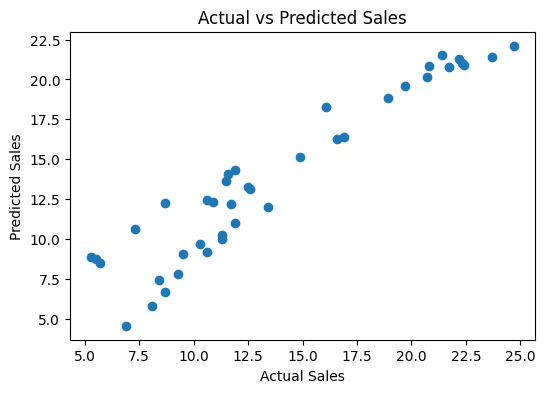

In [ ]:
plt.figure(figsize=(6,4))
plt.scatter(y_test, y_pred)
plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales")
plt.show()

## 📌 Conclusion
The Sales Prediction model successfully analyzed the impact of advertising expenditure on product sales. Linear Regression achieved good predictive performance, indicating that advertising investments, particularly in TV and Radio channels, significantly influence sales outcomes. The model can assist businesses in making data-driven marketing decisions.